### Ventanas Moviles

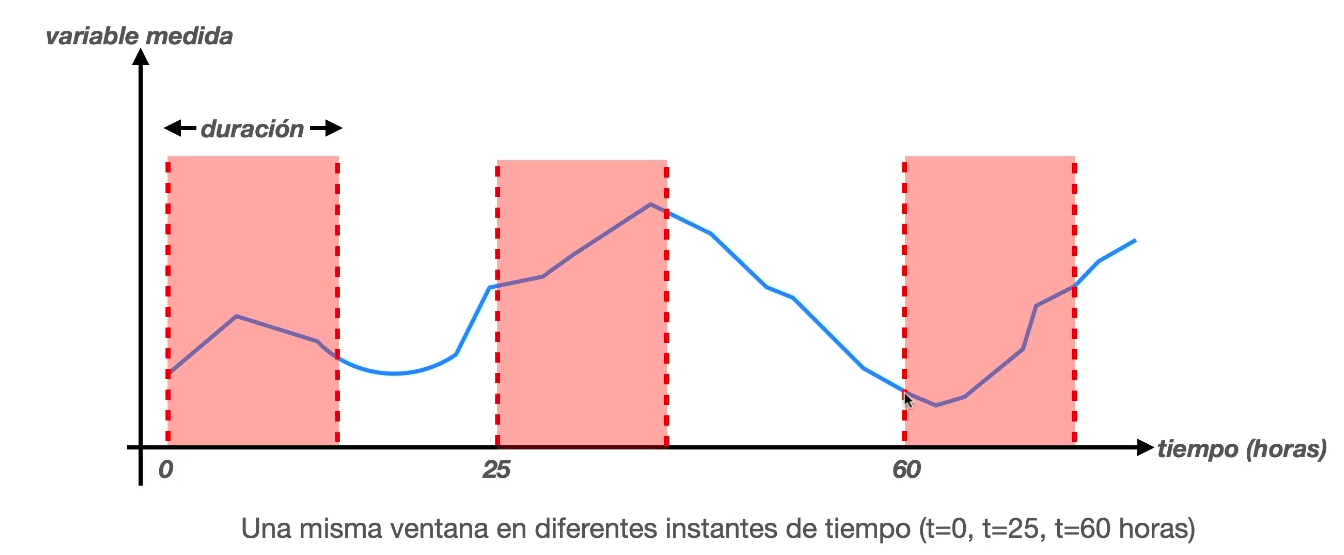

* Detección de patrones y tendencias

* Detección de anomalías

### rolling()

    * window: Define la duración de registros de la ventana 
    * step  : Define el tamaño del salto de la ventana

In [1]:
import pandas as pd

indice = pd.date_range('2023-01-01 10:00:00', periods = 6, freq='1h')
valores = [i+1 for i in range(6)]
df = pd.DataFrame(data = {'valores': valores}, index = indice)
df

,valores
2023-01-01 10:00:00,1
2023-01-01 11:00:00,2
2023-01-01 12:00:00,3
2023-01-01 13:00:00,4
2023-01-01 14:00:00,5
2023-01-01 15:00:00,6


In [2]:
df.rolling(3).mean()

,valores
2023-01-01 10:00:00,NaN
2023-01-01 11:00:00,NaN
2023-01-01 12:00:00,2.0
2023-01-01 13:00:00,3.0
2023-01-01 14:00:00,4.0
2023-01-01 15:00:00,5.0


In [3]:
df['media_movil'] = df.rolling(window = 3).mean()
df

,valores,media_movil
2023-01-01 10:00:00,1,NaN
2023-01-01 11:00:00,2,NaN
2023-01-01 12:00:00,3,2.0
2023-01-01 13:00:00,4,3.0
2023-01-01 14:00:00,5,4.0
2023-01-01 15:00:00,6,5.0


Ejercicio práctico:

    Procesar la temperatura del mes de Enero proveniente del set wheater_dataset.csv usando ventanas de 24 horas y para cada ventana determinar en qué instantes de tiempo su promedio sobrepasa el promedio de la temperatura del mes.

In [5]:
weather = pd.read_csv('../datos/weather_dataset.csv', 
                    parse_dates = ['datetime'],
                    index_col = 'datetime')
weather.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
datetime,,,,,,,,,,,,,,
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
2009-01-01 02:00:00,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
2009-01-01 03:00:00,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
2009-01-01 04:00:00,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
2009-01-01 05:00:00,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


In [ ]:
enero = weather['T (degC)']['2009-01']
enero

datetime
2009-01-01 01:00:00   -8.05
2009-01-01 02:00:00   -8.88
2009-01-01 03:00:00   -8.81
2009-01-01 04:00:00   -9.05
2009-01-01 05:00:00   -9.63
                       ... 
2009-01-31 19:00:00   -2.09
2009-01-31 20:00:00   -2.35
2009-01-31 21:00:00   -2.49
2009-01-31 22:00:00   -2.43
2009-01-31 23:00:00   -2.73
Name: T (degC), Length: 743, dtype: float64

In [ ]:
prom_enero = enero.mean()
print(f'Temperatura media de enero: {prom_enero}')

Temperatura media de enero: -3.608829071332436


In [ ]:
weather['sobrepasa_media'] = weather['T (degC)'].rolling('24h').apply(lambda x: x.mean() >= prom_enero)
### mejora sin usar una función definida


In [ ]:
weather.loc[:,['T (degC)', 'sobrepasa_media']]

,T (degC),sobrepasa_media
datetime,,
2009-01-01 01:00:00,-8.05,0.0
2009-01-01 02:00:00,-8.88,0.0
2009-01-01 03:00:00,-8.81,0.0
2009-01-01 04:00:00,-9.05,0.0
2009-01-01 05:00:00,-9.63,0.0
...,...,...
2009-02-21 13:00:00,1.43,1.0
2009-02-21 14:00:00,1.80,1.0
2009-02-21 15:00:00,1.72,1.0
